# Lab 2 (simplified) · Part 1 — Will there be low visibility at Malpensa in 3 hours?
### EUROCONTROL AI Lab · Exercise 2S-1: train the model

When visibility becomes very poor, airports switch to **Low-Visibility Procedures (LVP)**: runway capacity drops and arrivals may be regulated.
Knowing a few hours in advance helps the Network Manager, the airport and ATC.

**Question:** *from the weather report of this hour, what is the probability that visibility at Milano Malpensa will be below 1 500 m **3 hours from now**?*

We use real **METAR** reports (the hourly aviation weather report) of Malpensa, 2020–2025, archived by the
[Iowa Environmental Mesonet](https://mesonet.agron.iastate.edu/request/download.phtml) (Iowa State University).

> ⚠️ **Our target is a *proxy* for LVP, not LVP itself.** The data contains only weather observations: nothing says whether LVP were actually in force.
> Real LVP are declared by the aerodrome under local procedures, mainly based on runway visual range (RVR) and cloud ceiling.
> We use *"visibility below 1 500 m"* as a simple stand-in: the model predicts a **weather risk**, not an LVP declaration.

| | |
|---|---|
| ⏱ **Time** | about 1 h 15 |
| ➡️ **Next** | Part 2 opens the trained model and looks inside it · Part 3 turns it into a small service |

**What you will learn**
1. How to turn weather reports into **examples** for a model: inputs *now*, answer *3 hours later*.
2. Why **accuracy** misleads for rare events, and what **precision** and **recall** tell us instead.
3. How one setting, the **class weight**, changes the balance between *missed events* and *false alarms*.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

>
> 🧑‍💻 **Optional coding challenges** — a few cells invite those who want to **write code** to try a variation of the exercise.
> They are clearly marked, **switched off** (every line starts with `#`, so running them does nothing) and the rest of the notebook does not depend on them: skip them freely.
> To try one, remove the `#` signs (select the lines and press **Ctrl + /**, or **Cmd + /** on a Mac), fill in the `___` blanks and run the cell.
> The solutions are in the `solutions` folder next to this notebook.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab2s_low_visibility_simple/2S-1_train.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab2s_low_visibility_simple")# work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup

In [2]:
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import seaborn as sns                             # seaborn: heatmaps
import torch                                      # PyTorch: neural networks
import torch.nn as nn                             # building blocks of neural networks
from torch.utils.data import TensorDataset, DataLoader   # tools to feed the data in batches
from sklearn.metrics import precision_score, recall_score, confusion_matrix   # measures for yes/no forecasts

SEED = 42                                         # fixed seed for random numbers...
np.random.seed(SEED)                              # ...in numpy...
torch.manual_seed(SEED)                           # ...and in PyTorch, so results are reproducible

DATA_DIR = Path("../data")                        # the data folder sits next to this lab's folder
if not DATA_DIR.exists():                         # if not found (e.g. notebook opened from the solutions folder)...
    DATA_DIR = Path("../../data")                 # ...look one folder higher
LAB_DIR = Path(".")                               # this lab's folder...
if not (LAB_DIR / "lowvis_core.py").exists():     # ...or, from the solutions folder...
    LAB_DIR = Path("..")                          # ...the folder above
ARTIFACTS = LAB_DIR / "artifacts"                 # where the trained model will be saved
print("PyTorch version:", torch.__version__)      # show the PyTorch version

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

PyTorch version: 2.14.0+cu130


---
## 1 · Load the weather reports
One cell does it all: read the file, keep the routine report of every hour (issued at HH:50), and convert the US units of the archive
(°F, statute miles) into the units used in aviation (°C, metres).

In [3]:
raw = pd.read_csv(DATA_DIR / "LIMC.csv", na_values="M", low_memory=False)   # read the file; "M" means missing
raw["valid"] = pd.to_datetime(raw["valid"])                                 # observation time: text -> date/time

routine = raw[raw["valid"].dt.minute == 50]                   # keep only the routine hourly reports (HH:50)
routine = routine.drop_duplicates("valid")                    # remove any duplicated time
routine = routine.set_index("valid").sort_index()             # use the time as the row label, sorted
obs = routine.asfreq("h")                                     # one row per hour; missing hours become empty rows

weather = pd.DataFrame(index=obs.index)                       # a new table on the hourly timeline
weather["temperature_c"] = (obs["tmpf"] - 32) * 5 / 9         # temperature: °F -> °C
weather["dewpoint_c"] = (obs["dwpf"] - 32) * 5 / 9            # dew point: °F -> °C
weather["humidity_pct"] = obs["relh"]                         # relative humidity (%)
weather["wind_speed_kt"] = obs["sknt"]                        # wind speed (knots)
weather["visibility_m"] = obs["vsby"] * 1609.34               # visibility: statute miles -> metres

print("Hours from 2020 to 2025:", len(weather))               # size of the timeline
print("Example of a raw METAR message:", raw["metar"].iloc[4000])   # one original report, as pilots read it
weather.head()                                                # first 5 hours

Hours from 2020 to 2025: 52584
Example of a raw METAR message: LIMC 170050Z 33007KT 290V350 9999 RA BKN050 17/16 Q1011 NOSIG


,temperature_c,dewpoint_c,humidity_pct,wind_speed_kt,visibility_m
valid,,,,,
2020-01-01 00:50:00,-2.0,-2.0,100.0,6.0,9994.0014
2020-01-01 01:50:00,-2.0,-2.0,100.0,7.0,9994.0014
2020-01-01 02:50:00,-2.0,-2.0,100.0,5.0,9994.0014
2020-01-01 03:50:00,-3.0,-3.0,100.0,5.0,9994.0014
2020-01-01 04:50:00,-2.0,-2.0,100.0,5.0,9994.0014


*Dew point* = the temperature at which the air would become saturated. When temperature and dew point are close, the air is almost saturated — the condition for fog.

---
## 2 · A quick look at the data

### 2.1 How rare is low visibility?

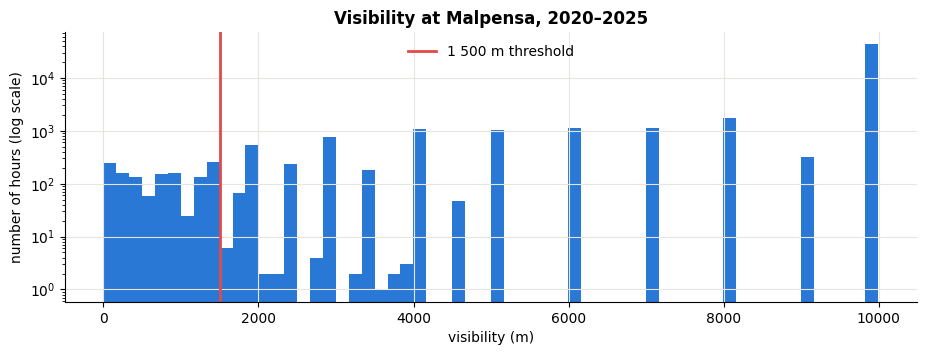

Hours with visibility below 1 500 m: 2.5 %


In [4]:
low_now = (weather["visibility_m"] < 1500).astype(float)      # 1 if visibility < 1500 m at that hour, otherwise 0
low_now[weather["visibility_m"].isna()] = np.nan              # keep "missing" where visibility is missing

plt.figure(figsize=(11, 3.5))                                 # new figure
plt.hist(weather["visibility_m"].dropna(), bins=60, color=PALETTE[0])   # how many hours at each visibility
plt.axvline(1500, color=PALETTE[7], linewidth=2, label="1 500 m threshold")   # red line at 1 500 m
plt.yscale("log")                                             # log scale, so small bars remain visible
plt.xlabel("visibility (m)")                                  # horizontal axis label
plt.ylabel("number of hours (log scale)")                     # vertical axis label
plt.title("Visibility at Malpensa, 2020–2025")                # title
plt.legend()                                                  # legend
plt.show()                                                    # display

print("Hours with visibility below 1 500 m:", round(low_now.mean() * 100, 1), "%")   # share of low-visibility hours

📖 **Reading:** most hours are on the far right — METAR reports "10 km or more" as `9999`. Low visibility happens in only about **2.5 % of the hours**:
it is a **rare event**. Keep this in mind when we measure the model.

### 2.2 When does it happen?

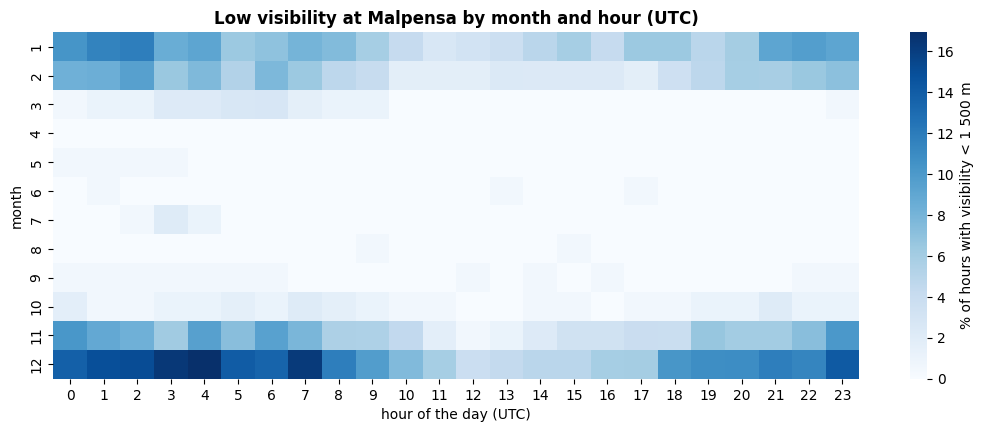

In [5]:
table = pd.DataFrame()                                        # an empty table
table["month"] = weather.index.month                          # month of each hour
table["hour"] = weather.index.hour                            # hour of the day (UTC)
table["low"] = low_now.values                                 # 1/0 low visibility
percent = table.pivot_table(index="month", columns="hour", values="low", aggfunc="mean") * 100   # % per month and hour

plt.figure(figsize=(13, 4.5))                                 # new figure
sns.heatmap(percent, cmap="Blues", cbar_kws={"label": "% of hours with visibility < 1 500 m"})   # coloured grid
plt.grid(False)                                               # no grid lines over the heatmap
plt.title("Low visibility at Malpensa by month and hour (UTC)")   # title
plt.xlabel("hour of the day (UTC)")                           # horizontal axis label
plt.ylabel("month")                                           # vertical axis label
plt.show()                                                    # display

📖 **Reading:** low visibility is a **winter, night-time** phenomenon (November–February, strongest around sunrise). So the **hour** and the **month** are useful inputs.

### 2.3 One foggy night, hour by hour

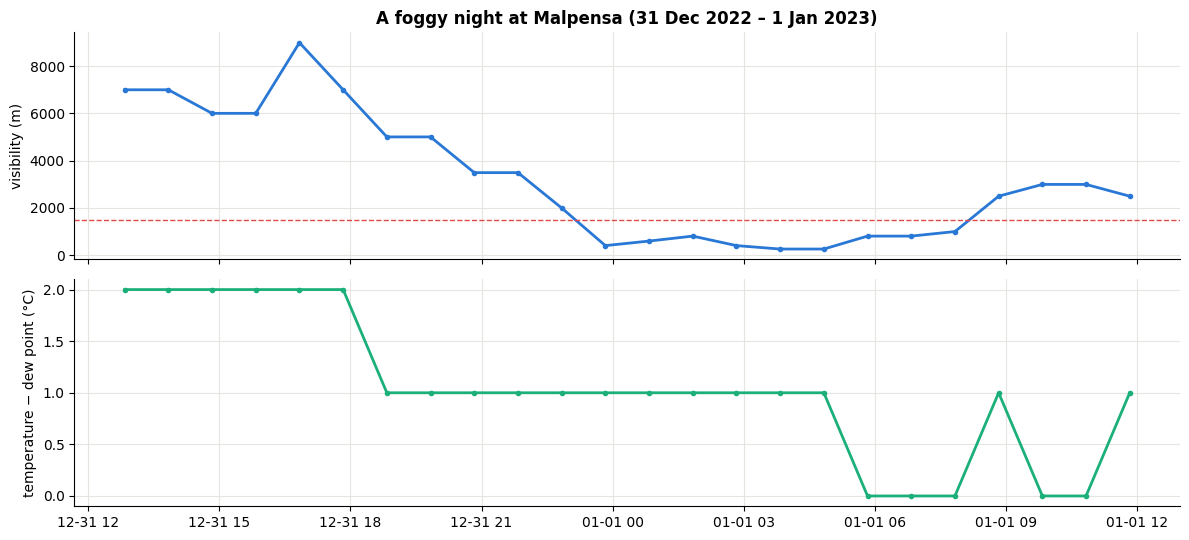

In [6]:
night = weather.loc["2022-12-31 12:00":"2023-01-01 12:00"]    # 24 hours around New Year's Eve 2022
spread = night["temperature_c"] - night["dewpoint_c"]         # temperature − dew point

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)   # two plots, one above the other
axes[0].plot(night.index, night["visibility_m"], marker="o", markersize=3, color=PALETTE[0])   # visibility
axes[0].axhline(1500, color=PALETTE[7], linestyle="--", linewidth=1)   # the 1 500 m threshold
axes[0].set_ylabel("visibility (m)")                          # label
axes[0].set_title("A foggy night at Malpensa (31 Dec 2022 – 1 Jan 2023)")   # title
axes[1].plot(night.index, spread, marker="o", markersize=3, color=PALETTE[2])   # temperature − dew point
axes[1].set_ylabel("temperature − dew point (°C)")            # label
plt.tight_layout()                                            # adjust spacing
plt.show()                                                    # display

📖 **Reading:** during the evening the air gets close to saturation (temperature − dew point around 0–1 °C) and visibility falls step by step,
dropping below 1 500 m just before midnight. Once formed, the fog **stays for about nine hours** and lifts in the morning.

### 🧑‍💻 Optional coding challenge A — low visibility and wind speed
*Optional, for those who want to write code — the rest of the notebook does not depend on it.*

**Task:** draw, for each wind speed (0, 1, 2 … 12 knots), the percentage of hours with visibility below 1 500 m. Is fog more frequent with calm wind?

Solution: `solutions/2S-1_train_SOLUTIONS.ipynb`

In [7]:
# 🧑‍💻 OPTIONAL CHALLENGE A — switched off: every line starts with "#", so running this cell does nothing.
# To try it: select all the lines below, press Ctrl + / (Cmd + / on a Mac) to remove the "#", replace each ___ and run.
#
# wind_rounded = weather["wind_speed_kt"].round()              # wind speed rounded to whole knots
# share = low_now.groupby(___).mean() * 100                    # % of low-visibility hours per wind speed (hint: wind_rounded)
# share = share[share.index <= 12]                             # keep 0–12 knots
#
# plt.figure(figsize=(8, 3.5))                                 # new figure
# plt.bar(share.index, share.values, color=PALETTE[0])         # one bar per wind speed
# plt.xlabel(___)                                              # hint: what is on the horizontal axis? (text in quotes)
# plt.ylabel("% of hours with visibility < 1 500 m")           # vertical axis label
# plt.title("Low visibility and wind speed")                   # title
# plt.show()                                                   # display

---
## 3 · Frame the problem

### 3.1 The question, on a timeline
We are at hour **t**: the METAR of this hour has just been issued. We know the weather **now**; we want to know the visibility **3 hours later**.

```
 time ──────────────────────────────────────────────────────────────────────────►

        KNOWN at time t                  │              FUTURE (unknown at time t)
                                         │
    …    t − 1 h         [ t ]           │      t + 1 h       t + 2 h       [ t + 3 h ]
                           │             │                                       │
                   METAR of time t       │                                  visibility
                           │             │                                       │
                           ▼             │                                       ▼
                INPUTS: 8 numbers        │                   TARGET = 1 if below 1 500 m, otherwise 0
                           │             │                                       ▲
                           └──────────► model ──► probability that the TARGET is 1
```

### 3.2 The 8 inputs (all from the report at time t)

| Input | What it is |
|---|---|
| `vis_m` | visibility **now** (m) |
| `spread_c` | temperature − dew point (°C): 0 = saturated air |
| `rh` | relative humidity (%) |
| `wind_kt` | wind speed (knots) |
| `hour_sin`, `hour_cos` | the hour of the day, placed on a **circle** |
| `month_sin`, `month_cos` | the month, placed on a **circle** |

**Why sine and cosine for the time?** If we gave the hour as a plain number, 23:00 (23) and 00:00 (0) would look very far apart, although they are one hour apart.
Placing the hours on a circle — like the hands of a clock — and giving the model the two coordinates of that point (cosine = left/right, sine = up/down) keeps neighbours close:

```
                    06:00
                      •
          03:00  •         •  09:00          hour_sin = up/down position on the circle
                                              hour_cos = left/right position on the circle
     00:00 •            ○            • 12:00
                                              23:00 and 00:00 are next to each other on the circle,
          21:00  •         •  15:00           just as they are on a clock
                      •
                    18:00
```
The same trick is used for the month, so that December and January are neighbours.

### 3.3 From the timeline to examples
Every hour becomes **one example**: the 8 inputs measured at that hour, and the target taken 3 hours later. Then we move one hour forward.
```
 example for 03:50:  [ 8 inputs measured at 03:50 ]  →  target: visibility at 06:50 below 1 500 m?  (1 or 0)
 example for 04:50:  [ 8 inputs measured at 04:50 ]  →  target: visibility at 07:50 below 1 500 m?
 example for 05:50:  [ 8 inputs measured at 05:50 ]  →  target: visibility at 08:50 below 1 500 m?
```
⚠️ The target comes from the **future**; the inputs must **never** contain future information — otherwise the model would look perfect here and fail in real use (**data leakage**).

In [8]:
features = pd.DataFrame(index=weather.index)                  # an empty table on the hourly timeline
features["vis_m"] = weather["visibility_m"].clip(upper=9999)  # visibility now, capped at 9999 m like in METAR
features["spread_c"] = weather["temperature_c"] - weather["dewpoint_c"]   # temperature − dew point
features["rh"] = weather["humidity_pct"]                      # humidity
features["wind_kt"] = weather["wind_speed_kt"]                # wind speed
hours = weather.index.hour                                    # hour of the day, 0–23
features["hour_sin"] = np.sin(2 * np.pi * hours / 24)         # hour on a circle (up/down)
features["hour_cos"] = np.cos(2 * np.pi * hours / 24)         # hour on a circle (left/right)
months = weather.index.month                                  # month, 1–12
features["month_sin"] = np.sin(2 * np.pi * months / 12)       # month on a circle (up/down)
features["month_cos"] = np.cos(2 * np.pi * months / 12)       # month on a circle (left/right)
FEATURES = list(features.columns)                             # the names of the 8 inputs

target = low_now.shift(-3)                                    # TARGET: the low-visibility flag 3 hours LATER

dataset = features.copy()                                     # copy the inputs...
dataset["target"] = target                                    # ...add the target...
dataset = dataset.dropna()                                    # ...and remove hours with missing values
print("Examples:", len(dataset), " | positive (target = 1):", round(dataset["target"].mean() * 100, 1), "%")   # size

Examples: 52014  | positive (target = 1): 2.5 %


**The target on the foggy night of §2.3.** The target of each hour looks 3 hours ahead, so it switches to 1 **three hours before** the fog arrives:

In [9]:
example = pd.DataFrame()                                      # an empty table
example["visibility now (m)"] = weather.loc["2022-12-31 17:50":"2023-01-01 01:50", "visibility_m"].round(0)   # visibility
example["TARGET: below 1 500 m in 3 h?"] = target.loc["2022-12-31 17:50":"2023-01-01 01:50"]                  # target
example                                                       # display

,visibility now (m),TARGET: below 1 500 m in 3 h?
valid,,
2022-12-31 17:50:00,7001.0,0.0
2022-12-31 18:50:00,5005.0,0.0
2022-12-31 19:50:00,5005.0,0.0
2022-12-31 20:50:00,3492.0,1.0
2022-12-31 21:50:00,3492.0,1.0
2022-12-31 22:50:00,1996.0,1.0
2022-12-31 23:50:00,402.0,1.0
2023-01-01 00:50:00,595.0,1.0
2023-01-01 01:50:00,805.0,1.0


### 3.4 How the data is split
By **time**: train on **2020–2023**, compare settings on **2024** (*validation*), and check the final model once on **2025** (*test*).

In [10]:
is_train = dataset.index < "2024-01-01"                       # True for 2020–2023
is_validation = (dataset.index >= "2024-01-01") & (dataset.index < "2025-01-01")   # True for 2024
is_test = dataset.index >= "2025-01-01"                       # True for 2025

X_all = dataset[FEATURES].values.astype("float32")            # all inputs as a table of numbers
y_all = dataset["target"].values.astype("float32")            # all targets (0/1)
print("Training:", is_train.sum(), "hours · validation:", is_validation.sum(), "· test:", is_test.sum())   # sizes

Training: 34663 hours · validation: 8712 · test: 8639


---
## 4 · How do we measure success?

The model gives a **probability**. We raise an **alert** when it is above a threshold (here **0.5**). Every hour then falls into one of four boxes:

|  | reality: low visibility at t+3 h | reality: no low visibility |
|---|---|---|
| **alert** | ✅ **hit** | ❌ **false alarm** |
| **no alert** | ❌ **miss** | ✅ **quiet hour, correctly quiet** |

- **Precision** = *when we raise an alert, how often is it right?* = hits ÷ (hits + false alarms)
- **Recall** = *of all the low-visibility cases, how many did we catch?* = hits ÷ (hits + misses)

⚠️ **Why not accuracy** (the share of hours answered correctly)? Because low visibility is rare: a "model" that **never** raises an alert is right ~97 % of the time — and catches nothing.

**A useful extra count — fog *onsets*.** Some cases are hours where visibility is fine **now** but will be low in 3 hours: the fog is about to **form**.
Those are the cases where an early warning is most valuable.

### 4.1 The baseline: persistence
The simplest forecast is ***"in 3 hours it will be like now"*** (**persistence**): alert if visibility is below 1 500 m now. Our model must be compared with it.

In [11]:
def evaluate(truth, alerts, visibility_now):                  # computes all our measures for one forecast
    hits = int(np.sum((alerts == 1) & (truth == 1)))          # alert and low visibility: a hit
    false_alarms = int(np.sum((alerts == 1) & (truth == 0)))  # alert but no low visibility: a false alarm
    misses = int(np.sum((alerts == 0) & (truth == 1)))        # no alert but low visibility: a miss
    onsets = (visibility_now >= 1500) & (truth == 1)          # fog onsets: fine now, low in 3 hours
    result = {}                                               # a dictionary for the results
    result["precision"] = round(precision_score(truth, alerts, zero_division=0), 2)   # share of alerts that were right
    result["recall"] = round(recall_score(truth, alerts), 2)  # share of cases caught
    result["hits"] = hits                                     # number of hits
    result["false alarms"] = false_alarms                     # number of false alarms
    result["misses"] = misses                                 # number of misses
    result["onsets caught"] = str(int(np.sum(alerts[onsets] == 1))) + " of " + str(int(np.sum(onsets)))   # onsets caught
    return result                                             # give the results back


vis_now_all = dataset["vis_m"].values                         # visibility now, for every example
persistence_all = (vis_now_all < 1500).astype(float)          # persistence: alert if visibility is low now

truth_val = y_all[is_validation]                              # true answers, validation year 2024
baseline = evaluate(truth_val, persistence_all[is_validation], vis_now_all[is_validation])   # persistence on 2024
pd.DataFrame([baseline], index=["persistence (2024)"])        # display as a one-row table

,precision,recall,hits,false alarms,misses,onsets caught
persistence (2024),0.49,0.5,96,99,97,0 of 97


📖 **Reading:** persistence catches about half of the cases and about half of its alerts are right — but it catches **0 fog onsets**, by construction:
if visibility is fine now, it never raises an alert. That is where a model can add value.

---
## 5 · Prepare the data for the network
Inputs are scaled around 0, using the average and spread of the **training** years only.

In [12]:
means = X_all[is_train].mean(axis=0)                          # average of each input (training years only)
stds = X_all[is_train].std(axis=0)                            # spread of each input (training years only)
X_scaled = (X_all - means) / stds                             # scale every input

train_data = TensorDataset(torch.tensor(X_scaled[is_train]), torch.tensor(y_all[is_train]))   # training examples for PyTorch
print("Training examples:", len(train_data))                  # how many

Training examples: 34663


---
## 6 · The neural network
A small network: **8 inputs → 16 neurons → 16 neurons → 1 output score**. The sigmoid function turns the score into a probability between 0 and 1.
(Part 2 of this lab opens this network and looks at every one of its weights.)

In [13]:
class FogNet(nn.Module):                                      # our neural network
    def __init__(self, n_inputs=8, hidden=16):                # runs when the model is created
        super().__init__()                                    # standard first line of every PyTorch model
        self.layer1 = nn.Linear(n_inputs, hidden)             # layer 1: 8 inputs -> 16 neurons
        self.layer2 = nn.Linear(hidden, hidden)               # layer 2: 16 -> 16 neurons
        self.output = nn.Linear(hidden, 1)                    # output layer: 16 -> 1 score
        self.relu = nn.ReLU()                                 # keeps positive values, sets negative ones to 0

    def forward(self, x):                                     # what the model does with a batch of inputs x
        h1 = self.relu(self.layer1(x))                        # values of the 16 neurons of layer 1
        h2 = self.relu(self.layer2(h1))                       # values of the 16 neurons of layer 2
        score = self.output(h2)                               # one score per example
        return score.squeeze(1)                               # shape (batch,)


model = FogNet()                                              # create one (untrained) model
count = 0                                                     # counter of weights
for p in model.parameters():                                  # for each group of weights...
    count = count + p.numel()                                 # ...add its size
print(model)                                                  # show the structure
print("Numbers the model will learn:", count)                 # show the total

FogNet(
  (layer1): Linear(in_features=8, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)
Numbers the model will learn: 433


---
## 7 · Training
`pos_weight` (the **class weight**) says how much a **missed** low-visibility hour should cost compared with a **false alarm**.
With `pos_weight = 1` both cost the same; with `pos_weight = 10`, one miss costs as much as ten false alarms.

In [14]:
def train_model(pos_weight=1.0, epochs=15, show_progress=False):   # trains one model and returns it
    torch.manual_seed(SEED)                                   # same random start for every run
    model = FogNet()                                          # a new, untrained model
    loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))   # loss for yes/no answers, with class weight
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # the optimizer that applies the corrections
    loader = DataLoader(train_data, batch_size=256, shuffle=True)   # batches of 256 examples, shuffled

    X_train = torch.tensor(X_scaled[is_train])                # training inputs
    y_train = torch.tensor(y_all[is_train])                   # training targets
    X_val = torch.tensor(X_scaled[is_validation])             # validation inputs
    y_val = torch.tensor(y_all[is_validation])                # validation targets
    history = {"training": [], "validation": []}              # loss after each epoch

    for epoch in range(epochs):                               # repeat for each epoch
        model.train()                                         # training mode
        for inputs, targets in loader:                        # for each batch:
            optimizer.zero_grad()                             #   1. reset the previous corrections
            scores = model(inputs)                            #   2. forward pass
            loss = loss_function(scores, targets)             #   3. how wrong are we?
            loss.backward()                                   #   4. compute the corrections
            optimizer.step()                                  #   5. apply them
        model.eval()                                          # evaluation mode
        with torch.no_grad():                                 # no corrections needed here
            history["training"].append(loss_function(model(X_train), y_train).item())    # loss on training years
            history["validation"].append(loss_function(model(X_val), y_val).item())      # loss on validation year
        if show_progress:                                     # if asked, print one line per epoch
            print("epoch", epoch, " training loss", round(history["training"][-1], 4),
                  " validation loss", round(history["validation"][-1], 4))   # [-1] = the last value
    return model, history                                     # give back the model and its learning curves


def alerts_of(model, rows):                                   # alerts (0/1) of a model for the selected rows
    model.eval()                                              # evaluation mode
    with torch.no_grad():                                     # prediction only
        probabilities = torch.sigmoid(model(torch.tensor(X_scaled[rows]))).numpy()   # probabilities
    return (probabilities >= 0.5).astype(float), probabilities   # alert if probability >= 0.5

### 7.0 · Watching the training loop at work
The training loop repeats the five steps for every batch: about 135 batches per epoch × 15 epochs, so **about 2 000 times**.
To **see** that at every step the model really receives inputs, gives answers and is compared with the truth, we run the **same five steps** once more,
with a few `print` instructions added.

> 🔍 **Only for studying — we print just a few of the steps.** Printing every step would give about 2 000 tables. We show only
> **the first batch of epochs 1, 2 and 15**, and only **a few of its 256 hours**: the first 4, plus up to 2 hours that were followed by low visibility
> (they are rare, so a batch has only a handful of them). Apart from the printing, the five steps are exactly those of `train_model`,
> and all the other batches and epochs run normally, without printing.
> This demonstration trains its own copy of the network (`watch_model`): nothing later in the notebook depends on it.

In [15]:
def show_batch(epoch_number, batch_number, number_of_batches, inputs, scores, targets, loss):   # prints one batch
    """Print what the model received, what it answered and the truth, for a few hours of one batch."""
    truth = targets.numpy()                                      # the truth of every hour of the batch (1 = low visibility in 3 h)
    rows = [0, 1, 2, 3]                                          # the first 4 hours of the batch...
    for i in range(len(truth)):                                  # ...plus the first 2 hours followed by low visibility
        if truth[i] == 1 and i not in rows and len(rows) < 6:    # (if the batch has any)
            rows.append(i)                                       # remember this hour
    X = inputs.numpy()[rows] * stds + means             # the inputs of these hours, back in real units
    table = pd.DataFrame(X.astype(float).round(2), columns=FEATURES)   # one column per input
    table.index = range(1, len(rows) + 1)                        # number the rows 1, 2, 3, ...
    probabilities = torch.sigmoid(scores).detach().numpy()       # the model's answers, as probabilities
    table["→ ANSWER (probability)"] = probabilities[rows].astype(float).round(3)   # what the model answered
    table["TRUTH (1 = low vis. in 3 h)"] = truth[rows].astype(int)   # what really happened
    print("EPOCH", epoch_number, "· batch", batch_number, "of", number_of_batches,
          "· loss of this batch:", round(loss.item(), 4),
          "· hours followed by low visibility in this batch:", int(truth.sum()), "of", len(truth))   # one summary line
    display(table)                                               # show the table under the cell


def train_one_epoch_and_show(model, loader, loss_function, optimizer, epoch_number, batches_to_show=1):   # loop + printout
    """Exactly the five training steps, plus a printout of the first batch(es)."""
    model.train()                                                # training mode
    batch_number = 0                                             # counts the batches of this epoch
    for inputs, targets in loader:                               # take the batches one by one
        batch_number = batch_number + 1                          # this is the next batch
        optimizer.zero_grad()                                    # 1. reset the previous corrections
        scores = model(inputs)                                   # 2. forward pass
        loss = loss_function(scores, targets)                    # 3. how wrong are we?
        if batch_number <= batches_to_show:                      # ONLY FOR STUDYING: for the first batch(es)...
            show_batch(epoch_number, batch_number, len(loader), inputs, scores, targets, loss)   # ...print them
        loss.backward()                                          # 4. compute the corrections
        optimizer.step()                                         # 5. apply them

In [16]:
torch.manual_seed(SEED)                                          # fixed random start, as in train_model
watch_model = FogNet()                                       # a new, untrained network, only for this demonstration
watch_loss_function = nn.BCEWithLogitsLoss()                     # the same loss as in train_model (pos_weight = 1)
watch_optimizer = torch.optim.Adam(watch_model.parameters(), lr=0.001)   # the same optimizer and learning rate
watch_loader = DataLoader(train_data, batch_size=256, shuffle=True)                                     # the same training batches as in train_model

EPOCHS_TO_SHOW = [1, 2, 15]                                      # the only epochs we print (studying only)
for epoch_number in range(1, 16):                                # 15 epochs, as in train_model
    if epoch_number in EPOCHS_TO_SHOW:                           # for the chosen epochs...
        train_one_epoch_and_show(watch_model, watch_loader, watch_loss_function, watch_optimizer, epoch_number)   # ...loop + printout
    else:                                                        # for all the other epochs...
        train_one_epoch_and_show(watch_model, watch_loader, watch_loss_function, watch_optimizer, epoch_number, batches_to_show=0)   # ...no printing

EPOCH 1 · batch 1 of 136 · loss of this batch: 0.6603 · hours followed by low visibility in this batch: 12 of 256


,vis_m,spread_c,rh,wind_kt,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,6002.84,3.0,82.62,12.0,0.50,-0.87,-0.87,0.50,0.481,0
2,9994.00,14.0,41.97,5.0,-0.87,-0.50,-0.50,-0.87,0.496,0
3,1995.58,0.0,100.00,3.0,0.71,0.71,-0.50,0.87,0.452,1
4,9994.00,13.0,45.34,5.0,-0.26,-0.97,-0.87,-0.50,0.494,0
5,1995.58,1.0,93.14,6.0,-0.71,0.71,0.00,1.00,0.473,1
6,6002.84,0.0,100.00,4.0,-0.87,-0.50,-0.50,0.87,0.480,1


EPOCH 2 · batch 1 of 136 · loss of this batch: 0.0895 · hours followed by low visibility in this batch: 2 of 256


,vis_m,spread_c,rh,wind_kt,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,9994.00,13.0,44.52,3.0,-0.71,-0.71,0.50,-0.87,0.036,0
2,9994.00,13.0,45.34,6.0,-1.00,0.00,-0.87,-0.50,0.064,0
3,9994.00,14.0,36.18,5.0,-0.87,-0.50,0.50,0.87,0.039,0
4,9994.00,1.0,93.30,4.0,-0.50,0.87,-0.50,0.87,0.065,0
5,3492.27,0.0,100.00,4.0,-0.97,0.26,0.50,0.87,0.236,1
6,1995.58,0.0,100.00,1.0,-0.50,0.87,-0.87,0.50,0.202,1


EPOCH 15 · batch 1 of 136 · loss of this batch: 0.0411 · hours followed by low visibility in this batch: 6 of 256


,vis_m,spread_c,rh,wind_kt,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,9994.00,1.0,93.40,1.0,0.97,0.26,0.0,1.00,0.002,0
2,7998.42,5.0,72.56,5.0,-1.00,0.00,0.5,-0.87,0.005,0
3,1207.00,0.0,100.00,6.0,-0.71,0.71,-0.5,0.87,0.278,0
4,9994.00,2.0,88.09,2.0,-0.50,0.87,-1.0,0.00,0.001,0
5,1995.58,1.0,93.40,1.0,-0.26,0.97,0.0,1.00,0.561,1
6,1207.00,1.0,93.19,2.0,-0.26,0.97,0.0,1.00,0.603,1


📖 **Reading:** each table is **one step of the loop, frozen for a moment**: on the left the 8 inputs the model received (shown back in real units: metres, °C, %, knots, and the sine/cosine of hour and month), then its **answer** — the probability of visibility below 1 500 m in 3 hours — and the **truth** (1 = it happened). The loss printed above the table is computed from the answers and truths of all 256 hours of the batch; right after the table, steps 4 and 5 use it to correct the weights.
- **Epoch 1:** the network is untrained, so it answers **about 0.5 for every hour** (0.45–0.50), whatever the inputs: clear afternoons and saturated foggy hours alike.
- **Epoch 2:** the answers for the ordinary hours have dropped to **about 0.05**, while the two hours that are followed by low visibility (saturated air, reduced visibility) get **about 0.2**: the network has started to use the inputs.
- **Epoch 15:** clear hours are at **0.00**, the two hours followed by low visibility get **about 0.6**, and an hour at 1 207 m whose visibility had **improved** 3 hours later (truth 0) gets 0.28 — close to a false alarm.

The batches are shuffled, so each table shows different hours. Remember that this is **only a window for studying**: in the real training (`train_model`) nothing is printed, but every one of the ~2 000 steps does exactly this.

### 7.1 · First training run
Back to the real training: the next cell trains the first model with `train_model`, using all the batches and epochs.

epoch 0  training loss 0.1266  validation loss 0.1167


epoch 1  training loss 0.0722  validation loss 0.0694


epoch 2  training loss 0.065  validation loss 0.0651


epoch 3  training loss 0.0624  validation loss 0.0636


epoch 4  training loss 0.0607  validation loss 0.0625


...

epoch 9  training loss 0.0578  validation loss 0.0608


epoch 10  training loss 0.0575  validation loss 0.0607
epoch 11  training loss 0.0574  validation loss 0.0608


epoch 12  training loss 0.0571  validation loss 0.0603


epoch 13  training loss 0.0568  validation loss 0.0604


epoch 14  training loss 0.0567  validation loss 0.0602


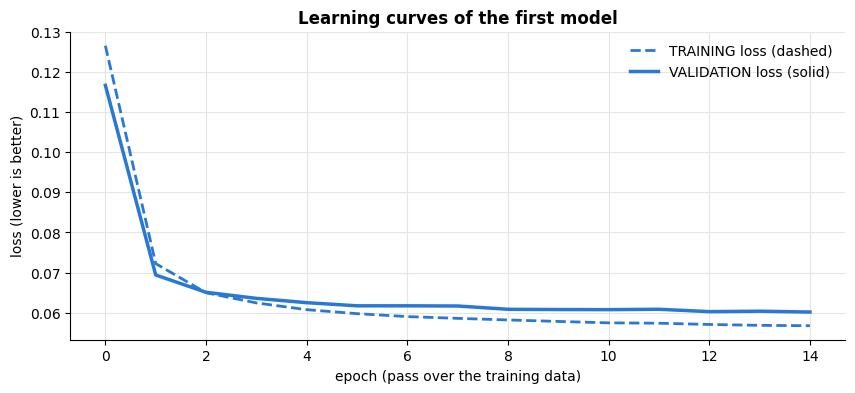

In [17]:
first_model, first_history = train_model(pos_weight=1.0, show_progress=True)   # first training run

plt.figure(figsize=(10, 4))                                   # new figure
plt.plot(first_history["training"], color=PALETTE[0], linestyle="--", label="TRAINING loss (dashed)")    # training
plt.plot(first_history["validation"], color=PALETTE[0], linewidth=2.5, label="VALIDATION loss (solid)")  # validation
plt.xlabel("epoch (pass over the training data)")             # horizontal axis label
plt.ylabel("loss (lower is better)")                          # vertical axis label
plt.title("Learning curves of the first model")               # title
plt.legend()                                                  # legend
plt.show()                                                    # display

📖 **Reading:** both losses drop quickly in the first epochs and then flatten: the model has learned what it can from these 8 inputs. The two curves stay close — no strong overfitting.

---
## 8 · The experiment: how much should a missed event cost?
We train three models that differ **only** in the class weight, and compare them with persistence on 2024.

In [18]:
weights = [1.0, 3.0, 10.0]                                    # three class weights to compare
models = {}                                                   # the trained models, by class weight
rows = []                                                     # one table row per model
labels = []                                                   # the row names
for w in weights:                                             # for each class weight...
    trained, history = train_model(pos_weight=w)              # ...train a model...
    models[w] = trained                                       # ...keep it...
    alerts, probabilities = alerts_of(trained, is_validation) # ...compute its alerts on 2024...
    rows.append(evaluate(truth_val, alerts, vis_now_all[is_validation]))   # ...and its measures
    labels.append("model, pos_weight " + str(w))              # row name
rows.append(baseline)                                         # add persistence for comparison
labels.append("persistence")                                  # its row name
pd.DataFrame(rows, index=labels)                              # display the comparison table (validation 2024)

,precision,recall,hits,false alarms,misses,onsets caught
"model, pos_weight 1.0",0.64,0.40,77,44,116,2 of 97
"model, pos_weight 3.0",0.42,0.61,118,161,75,24 of 97
"model, pos_weight 10.0",0.25,0.73,140,430,53,44 of 97
persistence,0.49,0.50,96,99,97,0 of 97


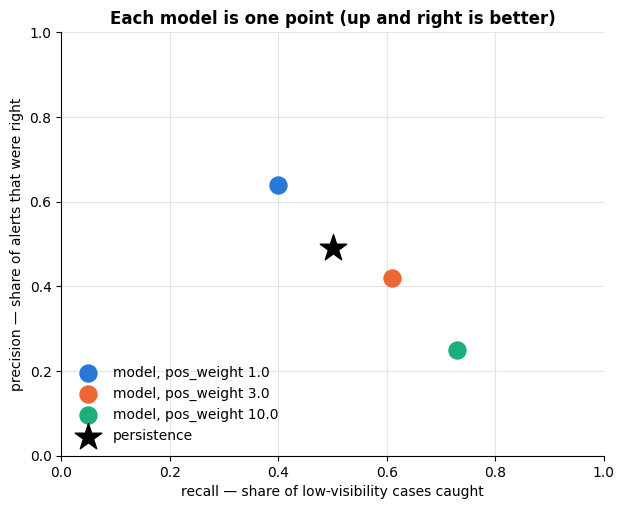

In [19]:
plt.figure(figsize=(7, 5.5))                                  # new figure
for i in range(len(weights)):                                 # for each model...
    r = rows[i]                                               # ...its measures
    plt.scatter(r["recall"], r["precision"], s=150, color=PALETTE[i], label=labels[i], zorder=3)   # one dot per model
plt.scatter(baseline["recall"], baseline["precision"], marker="*", s=400, color="black", label="persistence", zorder=4)   # star
plt.xlim(0, 1)                                                # recall from 0 to 1
plt.ylim(0, 1)                                                # precision from 0 to 1
plt.xlabel("recall — share of low-visibility cases caught")   # horizontal axis label
plt.ylabel("precision — share of alerts that were right")     # vertical axis label
plt.title("Each model is one point (up and right is better)") # title
plt.legend(loc="lower left")                                  # legend
plt.show()                                                    # display

📖 **Reading:**
- With **`pos_weight = 1`** the model is cautious: few false alarms, but it misses most of the cases.
- Raising the class weight moves the dot **to the right** (more cases caught, including **fog onsets** that persistence can never catch) and **down** (more false alarms).
- No setting is "correct": choosing between **missed events** and **false alarms** is an **operational decision**, to be taken with the people who will use the alerts.

For the rest of the lab we keep **`pos_weight = 3`** as a compromise: it catches more cases than persistence, including about a quarter of the fog onsets.

### 🧑‍💻 Optional coding challenge B — an even stronger class weight
*Optional, for those who want to write code.*

**Task:** train one more model with `pos_weight = 30` and compute its measures on 2024 with `evaluate`, following the loop above. How many false alarms does it raise?

Solution: `solutions/2S-1_train_SOLUTIONS.ipynb`

In [20]:
# 🧑‍💻 OPTIONAL CHALLENGE B — switched off: every line starts with "#", so running this cell does nothing.
# To try it: select all the lines below, press Ctrl + / (Cmd + / on a Mac) to remove the "#", replace each ___ and run.
#
# strong_model, strong_history = train_model(pos_weight=___)  # hint: 30.0
# strong_alerts, strong_probabilities = alerts_of(strong_model, ___)   # hint: the validation rows (is_validation)
# strong_result = evaluate(truth_val, strong_alerts, vis_now_all[is_validation])   # its measures
# print(strong_result)                                         # show them

### 8.1 The alert threshold is a second knob
Until now an alert meant *probability ≥ 0.5*. Moving this threshold changes the balance in the same way as the class weight:

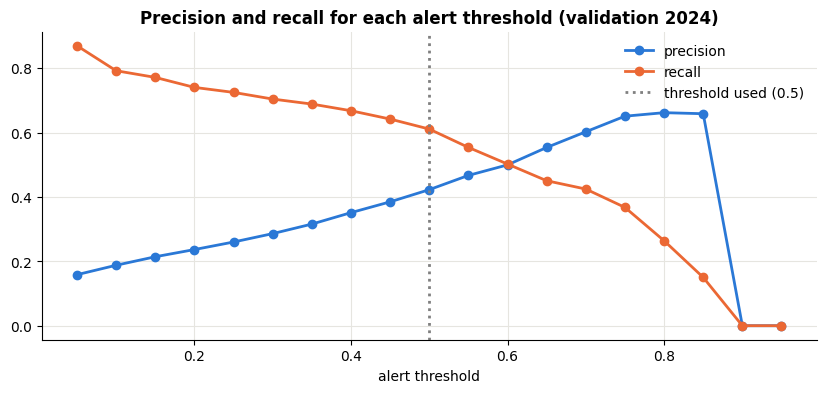

In [21]:
chosen = models[3.0]                                          # the model we keep (pos_weight 3)
alerts, probabilities = alerts_of(chosen, is_validation)      # its probabilities on 2024
thresholds = np.arange(0.05, 0.96, 0.05)                      # thresholds 0.05, 0.10, ..., 0.95
precisions = []                                               # precision at each threshold
recalls = []                                                  # recall at each threshold
for threshold in thresholds:                                  # for each threshold...
    alerts_here = (probabilities >= threshold).astype(float)  # ...the alerts...
    precisions.append(precision_score(truth_val, alerts_here, zero_division=0))   # ...their precision...
    recalls.append(recall_score(truth_val, alerts_here))      # ...and their recall

plt.figure(figsize=(10, 4))                                   # new figure
plt.plot(thresholds, precisions, marker="o", label="precision")   # precision curve
plt.plot(thresholds, recalls, marker="o", label="recall")     # recall curve
plt.axvline(0.5, color="grey", linestyle=":", label="threshold used (0.5)")   # the threshold we use
plt.xlabel("alert threshold")                                 # horizontal axis label
plt.title("Precision and recall for each alert threshold (validation 2024)")   # title
plt.legend()                                                  # legend
plt.show()                                                    # display

📖 **Reading:** a low threshold catches almost everything but with many false alarms; a high threshold gives few, reliable alerts but misses cases. We keep 0.5.

---
## 9 · Final test on 2025 (used only once)

In [22]:
truth_test = y_all[is_test]                                   # true answers, test year 2025
test_alerts, test_probabilities = alerts_of(chosen, is_test)  # alerts of our model on 2025
final = {}                                                    # a comparison table
final["our model"] = evaluate(truth_test, test_alerts, vis_now_all[is_test])                          # our model
final["persistence"] = evaluate(truth_test, persistence_all[is_test], vis_now_all[is_test])           # persistence
pd.DataFrame(final).T                                         # display, one row per method

,precision,recall,hits,false alarms,misses,onsets caught
our model,0.26,0.46,63,176,75,26 of 78
persistence,0.43,0.43,60,79,78,0 of 78


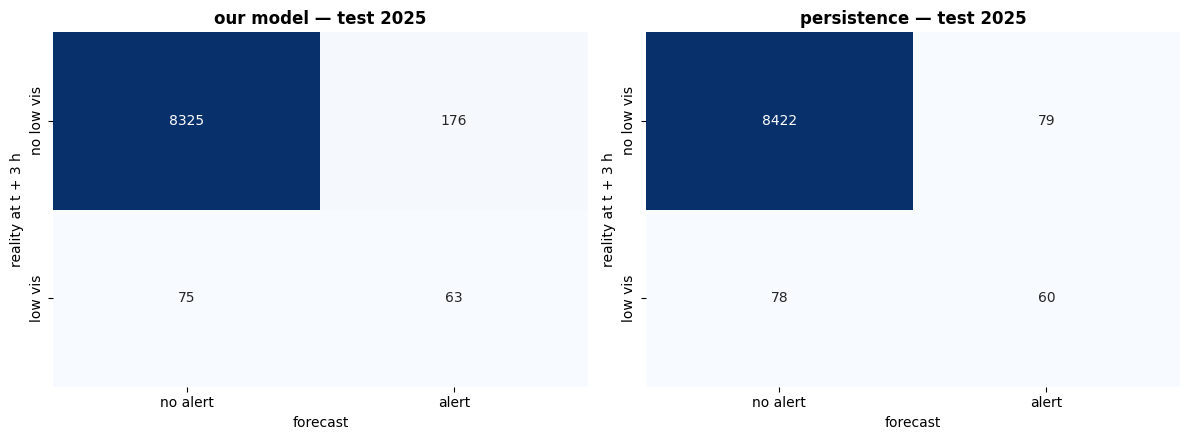

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))             # two plots side by side
names = [["our model", test_alerts], ["persistence", persistence_all[is_test]]]   # the two forecasts to show
for i in range(2):                                            # for each forecast...
    matrix = confusion_matrix(truth_test, names[i][1])        # ...count hits, misses, false alarms, quiet hours
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i],
                xticklabels=["no alert", "alert"], yticklabels=["no low vis", "low vis"])   # draw the four boxes
    axes[i].grid(False)                                       # no grid lines
    axes[i].set_title(names[i][0] + " — test 2025")           # title
    axes[i].set_xlabel("forecast")                            # horizontal axis label
    axes[i].set_ylabel("reality at t + 3 h")                  # vertical axis label
plt.tight_layout()                                            # adjust spacing
plt.show()                                                    # display

📖 **Reading:** each grid shows the four boxes of §4 — top-right = false alarms, bottom-left = misses, bottom-right = hits.
Our model catches more cases than persistence and some fog onsets, but raises more false alarms: the same trade-off seen on 2024.

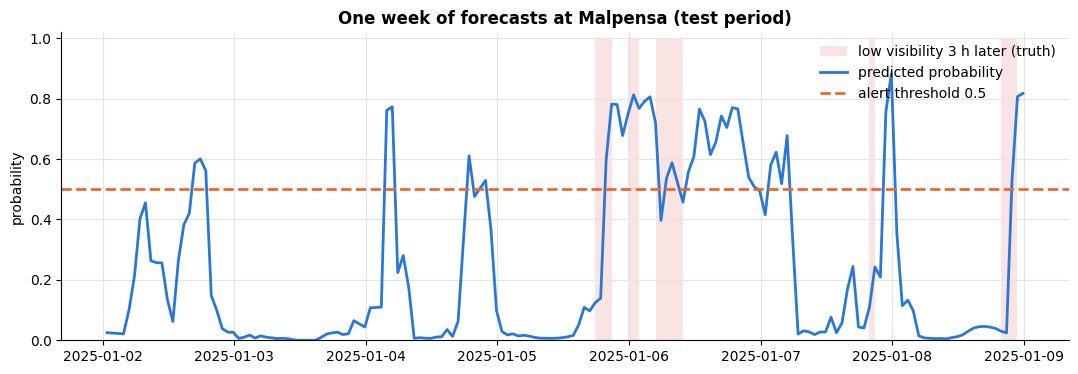

In [24]:
week = dataset[is_test].copy()                                # the test hours...
week["probability"] = test_probabilities                      # ...with the model's probability
week = week.loc["2025-01-02":"2025-01-08"]                    # one week of January 2025

plt.figure(figsize=(13, 4))                                   # new figure
plt.fill_between(week.index, 0, 1, where=week["target"] == 1, color=PALETTE[7], alpha=0.15, linewidth=0,
                 label="low visibility 3 h later (truth)")    # red shading where the target is 1
plt.plot(week.index, week["probability"], color=PALETTE[0], label="predicted probability")   # the model
plt.axhline(0.5, color=PALETTE[1], linestyle="--", label="alert threshold 0.5")   # threshold
plt.ylim(0, 1.02)                                             # vertical axis 0–1
plt.ylabel("probability")                                     # vertical axis label
plt.title("One week of forecasts at Malpensa (test period)")  # title
plt.legend(loc="upper right")                                 # legend
plt.show()                                                    # display

📖 **Reading:** the probability often rises before the red periods begin, and falls when the fog lifts. You can also spot false alarms and misses.

---
## 10 · Save the model for Parts 2 and 3
We save the learned weights **and** everything needed to use them correctly: the input list, the scaling values, the threshold — and what the target really means.

In [25]:
import sys                                                    # sys: lets Python find our shared file
sys.path.insert(0, str(LAB_DIR))                              # the folder that contains lowvis_core.py
import lowvis_core                                            # the shared code used by Parts 2 and 3

card = {}                                                     # the "model card": a description of the model
card["name"] = "Low-visibility nowcast LIMC, simplified (LVP proxy)"   # name
card["version"] = "1.0.0"                                     # version
card["task"] = "P(visibility < 1500 m exactly 3 hours after the METAR)"   # what it predicts
card["target_note"] = "Proxy for LVP, derived from METAR visibility only; real LVP depend on RVR, ceiling and local procedures."   # honesty
card["features"] = FEATURES                                   # the 8 inputs, in order
card["scaler_mean"] = means.tolist()                          # scaling averages
card["scaler_std"] = stds.tolist()                            # scaling spreads
card["hidden"] = 16                                           # neurons per layer
card["pos_weight"] = 3.0                                      # class weight used
card["threshold"] = 0.5                                       # alert threshold
card["test_2025"] = final["our model"]                        # results on the test year
card["intended_use"] = "Training exercise only. Not for operational use."   # allowed use
lowvis_core.save_model(chosen, card, ARTIFACTS)               # save weights + model card in the artifacts folder

saved = lowvis_core.SavedModel(ARTIFACTS)                     # load it back from disk, as Parts 2 and 3 will do
check = saved.probability(dataset[is_test])                   # its probabilities on 2025
print("Largest difference with the model in memory:", float(np.abs(check - test_probabilities).max()))   # should be ~0

Largest difference with the model in memory: 0.0


---
## 11 · Questions for discussion
1. Why is a model that is right 97 % of the time not automatically a good model here?
2. Our model catches more cases than persistence but raises more false alarms. Would an airport operator prefer it? What would you ask them?
3. The target is a **proxy** for LVP (visibility < 1 500 m in 3 hours). How could it differ from the real LVP decisions of the airport?

➡️ **Next: Part 2 — Inside the model.**